<a href="https://colab.research.google.com/github/dingyichuan7-dotcom/111/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP 4901Z:  Homework 1

**Instructions:** Complete all code blanks marked with **TODO** comments.


## 1.1 Multi-Armed Bandit Algorithm

In this section, you will implement and compare three action strategies for solving the Multi-Armed Bandit (MAB) problem:

1. **Greedy Algorithm** - Always selects the action with the highest estimated value
2. **ε-Greedy Algorithm** - Balances exploitation and exploration with a fixed exploration probability
3. **Decaying ε-Greedy Algorithm** - Reduces exploration over time as more information is gathered

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
class MultiArmedBandit:
    """
    Multi-Armed Bandit environment with K arms.
    Each arm follows a normal distribution with different means.
    """

    def __init__(self, k_arms: int = 10, variance: float = 1.0):
        """
        Initialize the bandit environment.

        Args:
            k_arms: Number of arms (actions)
            variance: Variance of the reward distributions
        """
        self.k_arms = k_arms
        self.variance = variance
        self.true_values = np.random.normal(0, 1, k_arms)

        self.optimal_arm = np.argmax(self.true_values)
        self.optimal_value = self.true_values[self.optimal_arm]

        print(f"Bandit initialized with {k_arms} arms")
        print(f"True action values: {self.true_values.round(3)}")
        print(f"Optimal arm: {self.optimal_arm} (value: {self.optimal_value:.3f})")

    def pull_arm(self, action: int) -> float:
        """
        Pull an arm and get a reward.

        Args:
            action: Which arm to pull (0 to k_arms-1)

        Returns:
            reward: Reward sampled from the arm's distribution
        """
        reward = np.random.normal(self.true_values[action], self.variance)
        return reward

    def is_optimal(self, action: int) -> bool:
        """Check if the selected action is optimal."""
        return action == self.optimal_arm


## Multi-Armed Bandit Algorithms Implementation

### 1. Greedy Algorithm

The **Greedy algorithm** always selects the action with the highest estimated value. It uses sample averages to estimate action values:

$$Q_t(a) = \frac{\text{sum of rewards for action } a}{\text{number of times action } a \text{ was selected}}$$

---

### 2. ε-Greedy Algorithm

The **ε-Greedy algorithm** balances exploration and exploitation with a fixed exploration probability:

- With probability $(1-\varepsilon)$: **Exploit** → choose the action with highest estimated value
- With probability $\varepsilon$: **Explore** → choose a random action

---

### 3. Decaying ε-Greedy Algorithm

The **Decaying ε-Greedy algorithm** reduces exploration over time as the agent gathers more information and becomes more confident in its estimates.

**Common decay schedules:**

- **Linear decay**: $\varepsilon_t = \varepsilon_0 \cdot \left(1 - \frac{t}{T}\right)$



In [ ]:
from abc import ABC
import numpy as np

class GreedyAgent(ABC):
    def __init__(self, k_arms: int):
        self.k_arms = k_arms
        self.q_estimates = np.zeros(k_arms)
        self.action_counts = np.zeros(k_arms)

    def update(self, action: int, reward: float):
        """Update Q-values, i.e., self.q_estimates"""
        # TODO your code
        # |‾‾‾‾‾‾‾‾‾|
        self.action_counts[action] += 1
        self.q_estimates[action] += (reward - self.q_estimates[action]) / self.action_counts[action]
        # |_________|

    def _greedy_action(self) -> int:
        """Select greedy action (highest Q-value)"""
        # TODO your code
        # |‾‾‾‾‾‾‾‾‾|
        return np.argmax(self.q_estimates)
        # |_________|

    def select_action(self, t: int = 0) -> int:
        return self._greedy_action()


class EpsilonGreedyAgent(GreedyAgent):
    """ε-Greedy agent with fixed exploration probability."""

    def __init__(self, k_arms: int, epsilon: float = 0.1):
        super().__init__(k_arms)
        self.epsilon = epsilon

    def select_action(self, t: int = 0) -> int:
        # TODO your code
        # |‾‾‾‾‾‾‾‾‾|
        if np.random.random() < self.epsilon:
            return np.random.randint(self.k_arms)
        else:
            return self._greedy_action()
        # |_________|


class DecayingEpsilonGreedyAgent(GreedyAgent):
    """Decaying ε-Greedy agent with time-decreasing exploration."""

    def __init__(self, k_arms: int, initial_epsilon: float = 0.1, decay_type: str = 'linear'):
        super().__init__(k_arms)
        self.initial_epsilon = initial_epsilon
        self.decay_type = decay_type

    def select_action(self, t: int = 0, max_steps=1000) -> int:
        # TODO your code
        # linear decay: ε = initial_epsilon * (1 - t / max_steps)
        # |‾‾‾‾‾‾‾‾‾|
        epsilon = self.initial_epsilon * (1 - t / max_steps)
        epsilon = max(0, epsilon)  # 确保 epsilon 不会变成负数

        if np.random.random() < epsilon:
            return np.random.randint(self.k_arms)
        else:
            return self._greedy_action()
        # |_________|

### Run Experiments and Collect Results

Now we'll run experiments with each algorithm to get statistically meaningful results.

In [ ]:
def run_agent(agent: GreedyAgent, bandit: MultiArmedBandit, num_steps: int = 1000) -> Dict:
    """
    Universal runner for any agent type.

    Args:
        agent: Any agent inheriting from BaseAgent
        bandit: MultiArmedBandit environment
        num_steps: Number of steps to run

    Returns:
        results: Dictionary with experimental results
    """
    rewards, actions, optimal_actions = [], [], []
    q_estimates_history = []
    extra_data = {}

    for t in range(num_steps):
        action = agent.select_action(t)
        reward = bandit.pull_arm(action)
        agent.update(action, reward)

        rewards.append(reward)
        actions.append(action)
        optimal_actions.append(bandit.is_optimal(action))
        q_estimates_history.append(agent.q_estimates.copy())

    results = {
        'rewards': np.array(rewards),
        'actions': np.array(actions),
        'optimal_actions': np.array(optimal_actions),
        'q_estimates_history': np.array(q_estimates_history),
        'final_q_estimates': agent.q_estimates,
        'action_counts': agent.action_counts
    }

    for key, value in extra_data.items():
        results[key] = np.array(value) if value else None

    return results


def run_experiment(num_runs: int = 100, num_steps: int = 1000, epsilon: float = 0.1) -> Dict:
    """
    Simplified experiment runner using the unified agent system.

    Args:
        num_runs: Number of independent runs for each algorithm
        num_steps: Number of steps per run
        epsilon: Exploration probability for ε-greedy

    Returns:
        results: Dictionary containing averaged results for all algorithms
    """
    print(f"Running {num_runs} experiments with {num_steps} steps each...")

    agent_configs = {
        'greedy': lambda k: GreedyAgent(k),
        'epsilon_greedy': lambda k: EpsilonGreedyAgent(k, epsilon=epsilon),
        'decaying_epsilon': lambda k: DecayingEpsilonGreedyAgent(k)
    }

    all_results = {name: {'rewards': [], 'optimal': []} for name in agent_configs.keys()}

    for run in range(num_runs):
        if run % 20 == 0:
            print(f"Completed {run}/{num_runs} runs...")

        bandit = MultiArmedBandit(k_arms=10, variance=1.0)

        for name, agent_factory in agent_configs.items():
            agent = agent_factory(bandit.k_arms)
            result = run_agent(agent, bandit, num_steps)

            all_results[name]['rewards'].append(result['rewards'])
            all_results[name]['optimal'].append(result['optimal_actions'])

    # Process results
    processed_results = {}
    for name in agent_configs.keys():
        rewards = np.array(all_results[name]['rewards'])
        optimal = np.array(all_results[name]['optimal'])

        processed_results[name] = {
            'avg_rewards': np.mean(rewards, axis=0),
            'std_rewards': np.std(rewards, axis=0),
            'avg_optimal': np.mean(optimal, axis=0),
            'cumulative_rewards': np.mean(np.cumsum(rewards, axis=1), axis=0)
        }

    # Add metadata
    processed_results.update({
        'num_runs': num_runs,
        'num_steps': num_steps,
        'epsilon': epsilon
    })

    return processed_results

# Run the experiments with refactored code
print("Starting experiments with refactored agents...")
results = run_experiment(num_runs=100, num_steps=1000, epsilon=0.1)
print("Experiments completed!")

Starting experiments with refactored agents...
Running 100 experiments with 1000 steps each...
Completed 0/100 runs...
Bandit initialized with 10 arms
True action values: [ 0.497 -0.138  0.648  1.523 -0.234 -0.234  1.579  0.767 -0.469  0.543]
Optimal arm: 6 (value: 1.579)
Bandit initialized with 10 arms
True action values: [ 0.126 -1.178  1.873  0.978  0.038 -0.274  0.199  0.518 -2.033  2.112]
Optimal arm: 9 (value: 2.112)
Bandit initialized with 10 arms
True action values: [ 0.891  1.121 -0.953 -0.536  0.284 -0.476 -1.929 -0.542  0.28   1.068]
Optimal arm: 1 (value: 1.121)
Bandit initialized with 10 arms
True action values: [ 0.582 -0.357  0.691 -1.492 -0.079 -1.055  1.025  0.374  0.65  -0.553]
Optimal arm: 6 (value: 1.025)
Bandit initialized with 10 arms
True action values: [ 0.138  0.365 -0.61  -2.528  1.035  0.503  0.713 -0.215  0.351 -2.   ]
Optimal arm: 4 (value: 1.035)
Bandit initialized with 10 arms
True action values: [ 0.32   0.484  1.506 -1.303  0.338 -0.647  0.43   0.431 -0

## Visualize Performance Comparison and Regret Analysis

Let's create comprehensive visualizations to compare the three algorithms across different metrics.

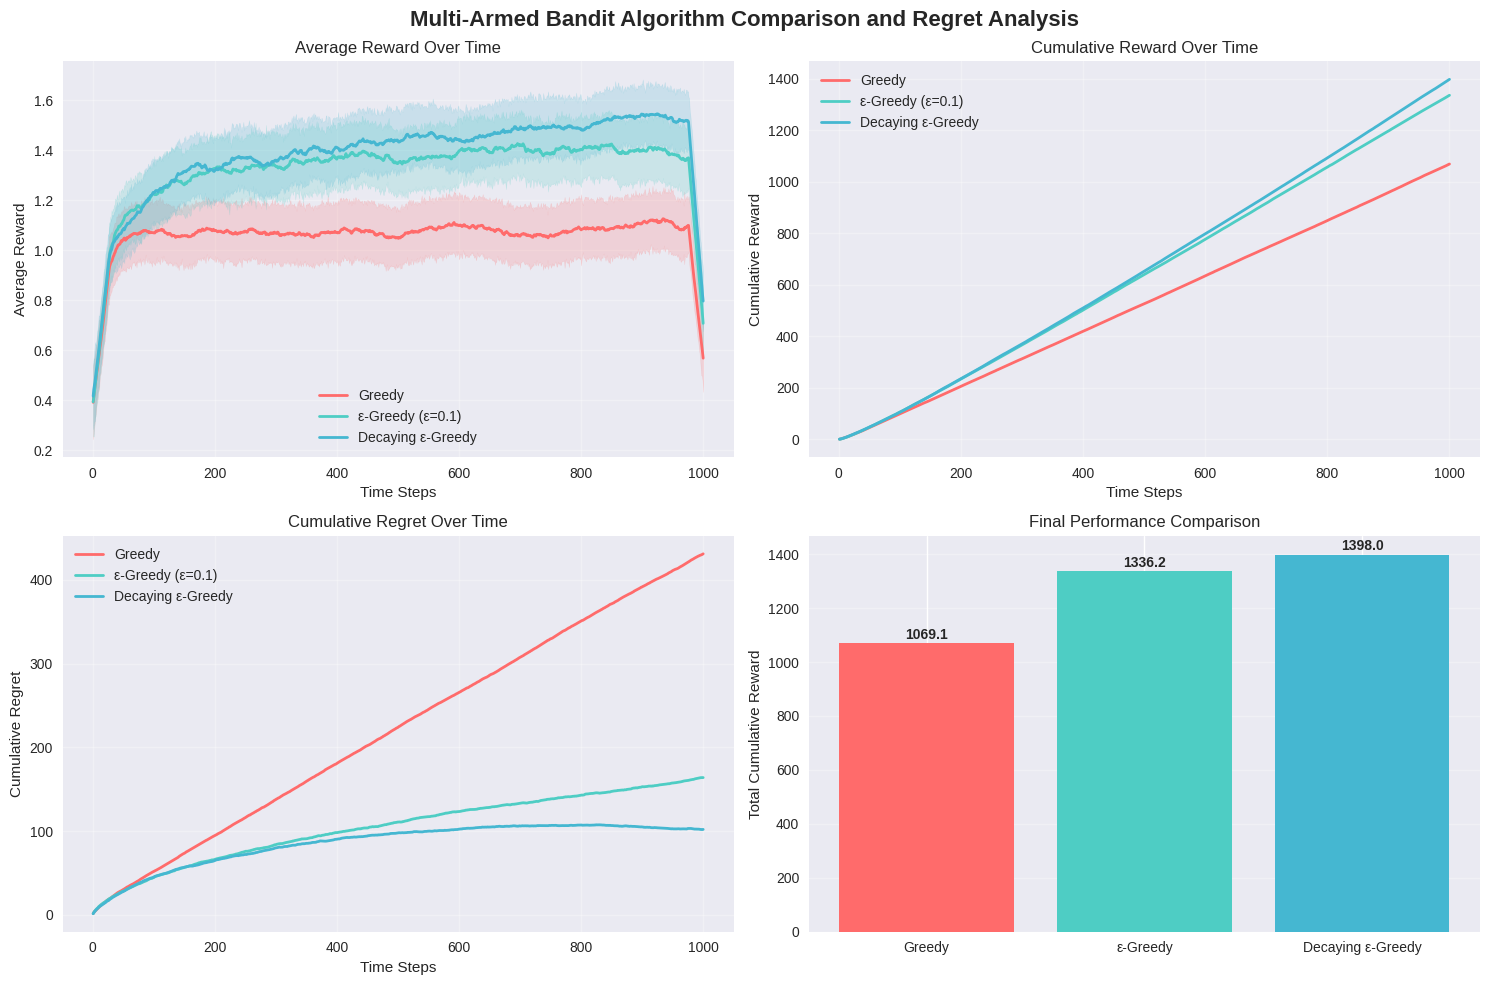

In [ ]:
def calculate_regret(results: Dict, optimal_reward: float = 1.5) -> Dict:
    """
    Calculate regret for each algorithm over time.

    Args:
        results: Results from experiments
        optimal_reward: Expected reward of optimal action (estimated)

    Returns:
        regret_results: Dictionary with regret calculations
    """
    regret_results = {}

    for algo in ['greedy', 'epsilon_greedy', 'decaying_epsilon']:
        # Calculate instantaneous regret
        instantaneous_regret = optimal_reward - results[algo]['avg_rewards']

        # Calculate cumulative regret
        cumulative_regret = np.cumsum(instantaneous_regret)

        regret_results[algo] = {
            'instantaneous_regret': instantaneous_regret,
            'cumulative_regret': cumulative_regret
        }

    return regret_results

def plot_comparison(results: Dict):
    """
    Create comprehensive comparison plots for the three algorithms including regret analysis.

    Args:
        results: Results dictionary from run_experiment()
    """
    time_steps = np.arange(1, results['num_steps'] + 1)

    # Calculate regret results
    regret_results = calculate_regret(results, optimal_reward=1.5)

    # Create figure with subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Multi-Armed Bandit Algorithm Comparison and Regret Analysis', fontsize=16, fontweight='bold')

    # Colors for each algorithm
    colors = {'greedy': '#FF6B6B', 'epsilon_greedy': '#4ECDC4', 'decaying_epsilon': '#45B7D1'}
    labels = {'greedy': 'Greedy', 'epsilon_greedy': f'ε-Greedy (ε={results["epsilon"]})',
              'decaying_epsilon': 'Decaying ε-Greedy'}

    # 1. Average Reward Over Time
    ax1 = axes[0, 0]
    for algo in ['greedy', 'epsilon_greedy', 'decaying_epsilon']:
        rewards = results[algo]['avg_rewards']
        std = results[algo]['std_rewards']

        # Plot running average (smooth the curve)
        window = 50
        smooth_rewards = np.convolve(rewards, np.ones(window)/window, mode='same')

        ax1.plot(time_steps, smooth_rewards, color=colors[algo],
                label=labels[algo], linewidth=2)
        ax1.fill_between(time_steps, smooth_rewards - std/np.sqrt(results['num_runs']),
                        smooth_rewards + std/np.sqrt(results['num_runs']),
                        alpha=0.2, color=colors[algo])

    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Average Reward')
    ax1.set_title('Average Reward Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Cumulative Reward
    ax2 = axes[0, 1]
    for algo in ['greedy', 'epsilon_greedy', 'decaying_epsilon']:
        cumulative = results[algo]['cumulative_rewards']
        ax2.plot(time_steps, cumulative, color=colors[algo],
                label=labels[algo], linewidth=2)

    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Cumulative Reward')
    ax2.set_title('Cumulative Reward Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Cumulative Regret Over Time
    ax3 = axes[1, 0]
    for algo in ['greedy', 'epsilon_greedy', 'decaying_epsilon']:
        cumulative_regret = regret_results[algo]['cumulative_regret']
        ax3.plot(time_steps, cumulative_regret, color=colors[algo],
                label=labels[algo], linewidth=2)

    ax3.set_xlabel('Time Steps')
    ax3.set_ylabel('Cumulative Regret')
    ax3.set_title('Cumulative Regret Over Time')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Final Performance Comparison (Bar Plot)
    ax4 = axes[1, 1]
    algorithms = ['Greedy', 'ε-Greedy', 'Decaying ε-Greedy']
    final_cumulative = [results['greedy']['cumulative_rewards'][-1],
                       results['epsilon_greedy']['cumulative_rewards'][-1],
                       results['decaying_epsilon']['cumulative_rewards'][-1]]

    bars = ax4.bar(algorithms, final_cumulative,
                   color=[colors['greedy'], colors['epsilon_greedy'], colors['decaying_epsilon']])
    ax4.set_ylabel('Total Cumulative Reward')
    ax4.set_title('Final Performance Comparison')
    ax4.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, final_cumulative):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Create the comparison plots
plot_comparison(results)

## 2.1 Network Packet Forwarding Decision MDP

### Scenario

A router needs to make decisions about incoming data packets. At each step (time), the router observes the **network congestion level**, **current packet priority**, and **current buffer queue length**, then selects an action to handle the packet: forward, drop, delay, or priority forward. The goal is to maximize cumulative reward (e.g., discounted return) in the long term.

### MDP Definition

- **State S**: Triple `(congestion, priority, queue)`
  - `congestion ∈ {Low(0), Medium(1), High(2)}`
  - `priority ∈ {High(0), Medium(1), Low(2)}`
  - `queue ∈ {Short(0), Medium(1), Long(2)}`
  - Total of `3×3×3=27` states.

- **Action A**:
  1. `Forward` (normal forwarding)
  2. `Drop` (discard)
  3. `Delay` (delay processing, put back in queue)
  4. `Priority_Forward` (priority forwarding, preempt resources)

- **Reward R** (core rules)
  - Successful forwarding: `+10`
  - Packet drop: penalty by priority, high/medium/low respectively `-20/-10/-5`
  - Failed forwarding under congestion (normal forward failure or priority forward failure): `-5`, `-7` respectively
  - Delay: `-2`
  - Successful priority forwarding: `+8` (slightly lower than normal success, indicating extra resource usage)

- **Transition T** (key, explicit and deterministic)
  - **Forward**:
    - Success probability: `p_succ = max(0.1, 0.9 - 0.3*congestion)` → Low/Med/High ≈ 0.9/0.6/0.3
    - Upon success: `queue' = max(0, queue-1)`; **Congestion drift**:
      - 70% remain unchanged
      - 15% decrease by one level (if already Low, merge into "remain")
      - 15% increase by one level (if already High, merge into "remain")
    - Upon failure: `queue' = min(2, queue+1)`, `congestion' = min(2, congestion+1)`

  - **Drop**:
    - Drop current packet, no queue change (simplified setting): `queue' = queue`, congestion unchanged: `congestion' = congestion`
    - Reward penalty based on priority.

  - **Delay**:
    - `queue' = min(2, queue+1)`, `congestion' = congestion`, reward `-2`

  - **Priority_Forward**:
    - Success probability: `p_succ = max(0.2, 0.95 - 0.2*congestion)` → Low/Med/High ≈ 0.95/0.75/0.55 (lower bound 0.2)
    - **Regardless of success or failure**: congestion will **increase by one level** (capped at High): `congestion' = min(2, congestion+1)`
    - Success: `queue' = max(0, queue-1)`, reward `+8`
    - Failure: `queue' = min(2, queue+1)`, reward `-7`

In [ ]:
from typing import List, Tuple


class NetworkRoutingEnv:
    """
    Network Packet Forwarding Decision MDP (deterministic transition list form)
    - 27 states: (congestion ∈ {0,1,2}, priority ∈ {0,1,2}, queue ∈ {0,1,2})
    - 4 actions: 0=Forward, 1=Drop, 2=Delay, 3=Priority_Forward
    - P[s][a] -> List of (prob, next_state, reward, done=False)
    """

    def __init__(self):
        self.nS = 27
        self.nA = 4
        self.action_names = ['Forward', 'Drop', 'Delay', 'Priority_Forward']
        self.level_names = ['Low', 'Medium', 'High']  # for all three dimensions
        self.P = self._build_P()

    # ---------- State index helpers ----------
    @staticmethod
    def _state_to_index(c: int, p: int, q: int) -> int:
        return c * 9 + p * 3 + q

    @staticmethod
    def _index_to_state(idx: int) -> Tuple[int, int, int]:
        c = idx // 9
        p = (idx % 9) // 3
        q = idx % 3
        return c, p, q

    # ---------- Utility: bounded inc/dec ----------
    @staticmethod
    def _inc_bounded(x: int, bound: int) -> int:
        return min(bound, x + 1)

    @staticmethod
    def _dec_bounded(x: int, lower: int = 0) -> int:
        return max(lower, x - 1)

    # ---------- Congestion drift after Forward success ----------
    def _congestion_drift_distribution(self, c: int) -> List[Tuple[float, int]]:
        """
        After a successful normal Forward, congestion may drift:
        - 70% stay
        - 15% decrease by 1 (if possible, otherwise added to 'stay')
        - 15% increase by 1 (if possible, otherwise added to 'stay')
        Returns a list of (prob, next_c).
        """
        stay = 0.70
        down = 0.15 if c > 0 else 0.0
        up   = 0.15 if c < 2 else 0.0
        spill = 0.15 * (1 if c == 0 else 0) + 0.15 * (1 if c == 2 else 0)
        stay += spill
        dist = []
        if down > 0: dist.append((down, c - 1))
        dist.append((stay, c))
        if up > 0:   dist.append((up, c + 1))
        # numeric safety
        s = sum(p for p, _ in dist)
        dist = [(p / s, cc) for p, cc in dist]
        return dist

    def _build_P(self) -> List[List[List[Tuple[float, int, float, bool]]]]:
        P = [[[] for _ in range(self.nA)] for _ in range(self.nS)]

        for c in range(3):         # congestion
            for p in range(3):     # priority (0 high / 1 med / 2 low)
                for q in range(3): # queue length
                    s = self._state_to_index(c, p, q)

                    # --------- Action 0: Forward ---------
                    succ_prob = max(0.1, 0.9 - 0.3 * c)  # 0.9/0.6/0.3
                    fail_prob = 1.0 - succ_prob

                    # success branch
                    q_succ = self._dec_bounded(q)  # queue -1
                    for pc, c_next in self._congestion_drift_distribution(c):
                        ns = self._state_to_index(c_next, p, q_succ)
                        P[s][0].append((succ_prob * pc, ns, 10.0, False))

                    # fail branch: congestion +1, queue +1
                    c_fail = self._inc_bounded(c, 2)
                    q_fail = self._inc_bounded(q, 2)
                    ns_fail = self._state_to_index(c_fail, p, q_fail)
                    P[s][0].append((fail_prob, ns_fail, -5.0, False))

                    # --------- Action 1: Drop ---------
                    # drop packet; queue & congestion unchanged
                    drop_penalty = -20.0 if p == 0 else (-10.0 if p == 1 else -5.0)
                    ns_drop = self._state_to_index(c, p, q)
                    P[s][1].append((1.0, ns_drop, drop_penalty, False))

                    # --------- Action 2: Delay ---------
                    q_delay = self._inc_bounded(q, 2)
                    ns_delay = self._state_to_index(c, p, q_delay)
                    P[s][2].append((1.0, ns_delay, -2.0, False))

                    # --------- Action 3: Priority_Forward ---------
                    psucc_pf = max(0.2, 0.95 - 0.2 * c)  # ~0.95/0.75/0.55
                    pfail_pf = 1.0 - psucc_pf
                    c_pf = self._inc_bounded(c, 2)  # congestion always goes up by 1

                    # success
                    q_pf_succ = self._dec_bounded(q)
                    ns_pf_succ = self._state_to_index(c_pf, p, q_pf_succ)
                    P[s][3].append((psucc_pf, ns_pf_succ, 8.0, False))

                    # fail
                    q_pf_fail = self._inc_bounded(q, 2)
                    ns_pf_fail = self._state_to_index(c_pf, p, q_pf_fail)
                    P[s][3].append((pfail_pf, ns_pf_fail, -7.0, False))

        return P



### Instructions:

Complete the **TODO** sections in the following functions:

1. **Policy Evaluation**

2. **Policy Improvement**

3. **Value Iteration Algorithm**

In [ ]:
import numpy as np
from typing import List, Tuple


def policy_evaluation(env: NetworkRoutingEnv, pi: np.ndarray, gamma=0.95, theta=1e-6, max_iter=10000):
    V = np.zeros(env.nS, dtype=np.float64)
    iter = 0
    # TODO your code
    # |‾‾‾‾‾‾‾‾‾|
    for iter in range(max_iter):
        delta = 0
        for s in range(env.nS):
            v = V[s]
            # 计算当前策略下的期望价值
            new_v = 0.0
            for a in range(env.nA):
                action_prob = pi[s, a]
                for prob, next_s, reward, done in env.P[s][a]:
                    new_v += action_prob * prob * (reward + gamma * V[next_s])
            V[s] = new_v
            delta = max(delta, abs(v - new_v))

        if delta < theta:
            break
    # |_________|
    return V, iter + 1


def policy_improvement(env: NetworkRoutingEnv, V: np.ndarray, gamma=0.95):
    pi = np.zeros((env.nS, env.nA), dtype=np.float64)
    # TODO your code
    # |‾‾‾‾‾‾‾‾‾|
    for s in range(env.nS):
        # 计算每个动作的动作价值函数 Q(s, a)
        q_values = np.zeros(env.nA)
        for a in range(env.nA):
            q = 0.0
            for prob, next_s, reward, done in env.P[s][a]:
                q += prob * (reward + gamma * V[next_s])
            q_values[a] = q

        # 选择最优动作（贪婪策略）
        best_a = np.argmax(q_values)
        pi[s, best_a] = 1.0  # 确定性策略
    # |_________|
    return pi
def policy_iteration(env: NetworkRoutingEnv, gamma=0.95, eval_theta=1e-8, max_outer=10000):
    tot_iter = 0
    pi = np.ones((env.nS, env.nA), dtype=np.float64) / env.nA  # init all to uniform distribution
    for it in range(max_outer):
        V, eval_iter = policy_evaluation(env, pi, gamma=gamma, theta=eval_theta)
        new_pi = policy_improvement(env, V, gamma=gamma)
        tot_iter += eval_iter
        if np.allclose(new_pi, pi, atol=1e-12):
            deterministic_pi = np.argmax(new_pi, axis=1)
            return V, deterministic_pi, tot_iter
        else:
            pi = new_pi
    return V, pi, max_outer

def value_iteration(env: NetworkRoutingEnv, gamma=0.95, theta=1e-6, max_iter=10000):
    V = np.zeros(env.nS, dtype=np.float64)
    pi = np.zeros(env.nS, dtype=np.int32)
    iter = 0
    # TODO your code
    # |‾‾‾‾‾‾‾‾‾|
    for iter in range(max_iter):
        delta = 0
        for s in range(env.nS):
            v = V[s]
            # 计算所有动作的 Q 值
            q_values = np.zeros(env.nA)
            for a in range(env.nA):
                q = 0.0
                for prob, next_s, reward, done in env.P[s][a]:
                    q += prob * (reward + gamma * V[next_s])
                q_values[a] = q

            # 取最大 Q 值作为新的 V(s)
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    # 提取最优策略
    for s in range(env.nS):
        q_values = np.zeros(env.nA)
        for a in range(env.nA):
            q = 0.0
            for prob, next_s, reward, done in env.P[s][a]:
                q += prob * (reward + gamma * V[next_s])
            q_values[a] = q
        pi[s] = np.argmax(q_values)
    # |_________|
    return V, pi, iter + 1

In [ ]:
env = NetworkRoutingEnv()
print(f"Env ready. States={env.nS}, Actions={env.nA} -> {env.action_names}")

# Policy Iteration
V_pi, pi_pi, it_pi = policy_iteration(env, gamma=0.95)
print(f"[Policy Iteration] Converged in {it_pi} iterations.")

# Value Iteration
V_vi, pi_vi, it_vi = value_iteration(env, gamma=0.95, theta=1e-8)
print(f"[Value Iteration] Converged in {it_vi} iterations.")

Env ready. States=27, Actions=4 -> ['Forward', 'Drop', 'Delay', 'Priority_Forward']
[Policy Iteration] Converged in 578 iterations.
[Value Iteration] Converged in 254 iterations.
